Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import upsetplot
from upsetplot import UpSet, from_indicators
from matplotlib_venn import venn2, venn3
import itertools
print(upsetplot.__version__)

0.9.0


Constants and Global variables

In [2]:
# Intergenic MECP2 constants
LIU_INTERGENIC = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\TE_Intergenic_With_Distances.bed"
XIANG_INTERGENIC = "C:\\Users\\Ana\\Documents\\Estágio\\Xiang2020\\TE_Intergenic_With_Distances.bed"
SUN_INTERGENIC = "C:\\Users\\Ana\\Documents\\Estágio\\Sun2023\\TE_Intergenic_With_Distances.bed"

# Intergenic RTT constants
ALDINGER_CINGLUATE_CORTEX_INTERGENIC = "C:\\Users\\Ana\\Documents\\Estágio\\Aldinger2020\\TE_Intergenic_With_Distances_Cingluate_cortex.bed"
ALDINGER_TEMPORAL_CORTEX_INTERGENIC = "C:\\Users\\Ana\\Documents\\Estágio\\Aldinger2020\\TE_Intergenic_With_Distances_Temporal_cortex.bed"
GOGLIOTI_CEREBELLUM_INTERGENIC = "C:\\Users\\Ana\\Documents\\Estágio\\Goglioti2018\\TE_Intergenic_With_Distances_Cerebellum.bed"
GOGLIOTI_MOTOR_CORTEX_INTERGENIC = "C:\\Users\\Ana\\Documents\\Estágio\\Goglioti2018\\TE_Intergenic_With_Distances_Motor_cortex.bed"
RODRIGUES_NPC_INTERGENIC = "C:\\Users\\Ana\\Documents\\Estágio\\Rodrigues2020\\TE_Intergenic_With_Distances_NPC.bed"
RODRIGUES_NEU_INTERGENIC = "C:\\Users\\Ana\\Documents\\Estágio\\Rodrigues2020\\TE_Intergenic_With_Distances_Neu.bed"
TANAKA_INTERGENIC = "C:\\Users\\Ana\\Documents\\Estágio\\Tanaka2014\\TE_Intergenic_With_Distances.bed"


# DEA TE MECP2 constants
SUN_TE_DEA = "C:\\Users\\Ana\\Documents\\Estágio\\Sun2023\\DEA_TE_DESeq.csv"
XIANG_TE_DEA = "C:\\Users\\Ana\\Documents\\Estágio\\Xiang2020\\DEA_TE_DESeq.csv"
LIU_TE_DEA_MECP2_KO ="C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\Liu2024_KO\\DEA_TE_DESeq_KO.csv"
LIU_TE_DEA_MECP2_R133C = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\Liu2024_R133C\\DEA_TE_DESeq_R133C.csv"
LIU_TE_DEA_MECP2_R168X = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\Liu2024_R168X\\DEA_TE_DESeq_R168X.csv"

# DEA TE RTT constants
ALDINGER_TE_CINGLUATE_CORTEX_DEA = "C:\\Users\\Ana\\Documents\\Estágio\\Aldinger2020\\Aldinger2020_Cingluate_cortex\\DEA_TE_DESeq_Cingluate_cortex.csv"
ALDINGER_TE_TEMPORAL_CORTEX_DEA = "C:\\Users\\Ana\\Documents\\Estágio\\Aldinger2020\\Aldinger2020_Temporal_cortex\\DEA_TE_DESeq_Temporal_cortex.csv"
GOGLIOTI_TE_CEREBELLUM_DEA = "C:\\Users\\Ana\\Documents\\Estágio\\Goglioti2018\\Goglioti2018_Cerebellum\\DEA_TE_DESeq_Cerebellum.csv"
GOGLIOTI_TE_MOTOR_CORTEX_DEA = "C:\\Users\\Ana\\Documents\\Estágio\\Goglioti2018\\Goglioti2018_Motor_cortex\\DEA_TE_DESeq_Motor_cortex.csv"
RODRIGUES_TE_NEU_DEA = "C:\\Users\\Ana\\Documents\\Estágio\\Rodrigues2020\\Rodrigues2020_Neu\\DEA_TE_DESeq_Neu.csv"
RODRIGUES_TE_NPC_DEA = "C:\\Users\\Ana\\Documents\\Estágio\\Rodrigues2020\\Rodrigues2020_NPC\\DEA_TE_DESeq_NPC.csv"
TANAKA_TE_DEA = "C:\\Users\\Ana\\Documents\\Estágio\\Tanaka2014\\DEA_TE_DESeq.csv"


# DEA Genes MECP2 constants
SUN_GENES_DEA = "C:\\Users\\Ana\\Documents\\Estágio\\Sun2023\\DEA_Genes_DESeq.csv"
XIANG_GENES_DEA = "C:\\Users\\Ana\\Documents\\Estágio\\Xiang2020\\DEA_Genes_DESeq.csv"
LIU_GENES_DEA_MECP2_KO = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\Liu2024_KO\\DEA_Genes_DESeq_KO.csv"
LIU_GENES_DEA_MECP2_R133C = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\Liu2024_R133C\\DEA_Genes_DESeq_R133C.csv"
LIU_GENES_DEA_MECP2_R168X = "C:\\Users\\Ana\\Documents\\Estágio\\Liu2024\\Liu2024_R168X\\DEA_Genes_DESeq_R168X.csv"

# DEA Genes RTT constants
ALDINGER_GENES_CINGLUATE_CORTEX_DEA = "C:\\Users\\Ana\\Documents\\Estágio\\Aldinger2020\\Aldinger2020_Cingluate_cortex\\DEA_Genes_DESeq_Cingluate_cortex.csv"
ALDINGER_GENES_TEMPORAL_CORTEX_DEA = "C:\\Users\\Ana\\Documents\\Estágio\\Aldinger2020\\Aldinger2020_Temporal_cortex\\DEA_Genes_DESeq_Temporal_cortex.csv"
GOGLIOTI_GENES_CEREBELLUM_DEA = "C:\\Users\\Ana\\Documents\\Estágio\\Goglioti2018\\Goglioti2018_Cerebellum\\DEA_Genes_DESeq_Cerebellum.csv"
GOGLIOTI_GENES_MOTOR_CORTEX_DEA = "C:\\Users\\Ana\\Documents\\Estágio\\Goglioti2018\\Goglioti2018_Motor_cortex\\DEA_Genes_DESeq_Motor_cortex.csv"
RODRIGUES_GENES_NEU_DEA = "C:\\Users\\Ana\\Documents\\Estágio\\Rodrigues2020\\Rodrigues2020_Neu\\DEA_Genes_DESeq_Neu.csv"
RODRIGUES_GENES_NPC_DEA = "C:\\Users\\Ana\\Documents\\Estágio\\Rodrigues2020\\Rodrigues2020_NPC\\DEA_Genes_DESeq_NPC.csv"
TANAKA_GENES_DEA = "C:\\Users\\Ana\\Documents\\Estágio\\Tanaka2014\\DEA_Genes_DESeq.csv"




Intersect TE function

In [ ]:

def merge_intergenic_with_dea(df_strings, dea_dfs):
    """Gets the intergenic TEs and merges them with the DEA"""

    intergenic_dfs = []
    dea_dfs = rename_deas(dea_dfs)

    for i in range(len(df_strings)):
        df = pd.read_csv(df_strings[i], sep = '\t', header = None)
        print(df.head())
        df.columns = ['TE_Chr', 'TE_Start', 'TE_End', 'TE_Name', 'TE_Score', 'TE_Strand', 'TE_Class-id', 'TE_Family_id',
                 'Gene_Chr', 'Gene_Start', 'Gene_End', 'Gene_Name', 'Gene_Score', 'Gene_Strand', 'Distances']
        
        df['TE_Classification'] = np.where(df['Distances'] <= 4000, 'proximal', 'intergenic')
        # df = df[df['TE_Classification'] == 'intergenic'] # Comment this line if you don't want to make only intergenic!
        df = df[['TE_Name', 'TE_Chr', 'TE_Classification']]
                
        intergenic_dfs.append(df)
        dea_dfs[i] = dea_dfs[i].merge(df, on = 'TE_Name', how = 'inner')
        print('Test TE_Classification')
        print(dea_dfs[i])

    return intergenic_dfs, dea_dfs
        

def rename_deas(dea_dfs):
    """Renames all the deas on the array"""

    for i in range(len(dea_dfs)):
        dea_dfs[i] = dea_dfs[i].rename(columns = {'Unnamed: 0' : 'TE_Name'})

    return dea_dfs

def get_merged_df(dfs):
    """Gets the merged final df"""

    merged_df = dfs[0]

    for df in dfs[1:]:
        merged_df = merged_df.merge(df['TE_Name'], on = 'TE_Name', how = 'inner')
    
    return merged_df


def get_merged_TE_DataFrame(df_strings):
    dfs = merge_intergenic_with_dea(df_strings)
    return get_merged_df(dfs)

DEA functions

In [ ]:

def read_deas(dea_strings):
    """Read the deas"""

    dfs = []
    names = []
    count = 0

    for string in dea_strings:
        # Read deas
        df = pd.read_csv(string)
        df = df.dropna()
        df = organize_classification(df)

        dfs.append(df)
        count += df.shape[0]

        # Get the data set name
        parts = string.split("\\")
        name = parts[-2]
        names.append(name)
        
    print(f"Número de TEs: {count}")
    return dfs, names

def organize_classification(dea_df):
    """Organizes the classification, according to the defined values"""

    dea_df['-log10(padj)'] = -np.log10(dea_df['padj'])

    dea_df['Classification'] = dea_df.apply(
        lambda row:
        'Up-regulated' if (row['log2FoldChange'] > 0 and row['padj'] < 0.05)
        else 'Down-regulated' if (row['log2FoldChange'] < 0 and row['padj'] < 0.05)
        else 'Non-significant',
        axis = 1
    )
    
    dea_df = dea_df[dea_df['Classification'] != 'Non-significant']

    return dea_df

def concat_deas(dea_dict):
    """Concat all the deas"""

    for name, dea in dea_dict.items(): # Preciso do items para conseguir também o value
        dea['DataSet'] = name

    df_all = pd.concat(dea_dict.values())
    return df_all



Counts function

In [ ]:
def print_counts(ax):
    """Prints the counts directly on the graph (because show_counts isn't working))"""

    patches = ax.patches

    for patch in patches:
        height = patch.get_height()
        position_x = patch.get_x() + patch.get_width() / 2
        ax.annotate(f'{int(height)}', (position_x, height), ha = 'center', va = 'bottom', 
                    xytext = (0, 5), textcoords = 'offset points')

Upset Plot function

In [ ]:

def print_genes_of_interest(df_all, presence_df, file_name, num_intersection = None, names_intersection = None):
    """
    Gets the DEGs or DETEs of interest into a csv.
    If you want to only see the DEGs or DETEs that are present in all data sets except a certain number, fill in the num_intersection parameter
    If you want to see the DEG or DETEs that are present in two different anatomic regions from a dataset, fill in names_intersection
    """

    # Organize presence_df
    datasets = list(presence_df.columns)
    presence_df_sorted = presence_df.sort_values(by = datasets, ascending = False)

    df_all_classification = (df_all[['TE_Name', 'Classification', 'DataSet']])

    presence_df_sorted = presence_df_sorted.merge(df_all_classification, on = 'TE_Name', how = 'inner')
    
    # Get all the detes that intersect all the data sets except a certain number (num_intersection)
    if (num_intersection != None):
        dfs = get_intersection_by_number(num_intersection, presence_df_sorted, datasets, file_name)
    
    # Get all the detes that intersect a certain specific data set
    else:
        dfs = get_intersection_by_name(names_intersection, presence_df_sorted, file_name)

    return dfs


def get_intersection_by_number(num_intersection, presence_df_sorted, datasets, file_name):
    """Gets the DETEs or DEGs that intersect all datasets except a certain number"""

    # Get the number of datasets the TE is present in
    num_columns = len(datasets)
    presence_per_te = presence_df_sorted[datasets].sum(axis = 1) # Diz a quantos data sets pertence o TE

    # Create initial data frame for concat
    all_intersect_df = pd.DataFrame(columns = ['TE_Name', 'Classification', 'DataSet'])
    all_intersect_df = all_intersect_df.pivot(index = 'TE_Name', columns = 'DataSet', values = 'Classification')

    dfs = []
    
    # Get all the tes that intersect all the data sets except a certain number (num_intersection)
    if (num_intersection != None):
        for i in range(num_intersection + 1): # Pq o último número não está incluído
            intersect_df = presence_df_sorted[presence_per_te == num_columns - i] # Extrai apenas as linhas que pertencem ao número de data sets que queremos
            intersect_df = intersect_df[['TE_Name', 'Classification', 'DataSet']]

            intersect_df = intersect_df.pivot(index = 'TE_Name', columns = 'DataSet', values = 'Classification')
            all_intersect_df = pd.concat([all_intersect_df, intersect_df])
    
    if (file_name is not None):
        all_intersect_df.to_csv(file_name, index = True)
    dfs.append(all_intersect_df)
    return dfs



def get_intersection_by_name(names, presence_df_sorted, file_name):
    """Gets DETEs or DEGs in a csv that intersect all different Gogliotti2018 or Rodrigues2020 subsets"""
    dfs = []
    datasets = []

    for name in names:
        if (name == "Goglioti"):
            datasets = ['Goglioti2018_Cerebellum', "Goglioti2018_Motor_cortex"]
        
        elif (name == "Rodrigues"):
            datasets = ['Rodrigues2020_Neu', "Rodrigues2020_NPC"]
        
        active_num = presence_df_sorted[datasets].sum(axis = 1) # Number of datasets between the ones i want to filter, the te is in

        other_columns = [column for column in presence_df_sorted.columns if column not in datasets]
        to_remove = ['TE_Name', 'Classification', 'DataSet']
        other_columns = [column for column in other_columns if column not in to_remove]

        intersect_df = presence_df_sorted[(active_num == len(datasets)) & (presence_df_sorted[other_columns].sum(axis = 1) == 0)]
        intersect_df = intersect_df[['TE_Name', 'Classification', 'DataSet']]
        intersect_df = intersect_df.pivot(index = 'TE_Name', columns = 'DataSet', values = 'Classification')
        
        intersect_df.to_csv(f"{name}_{file_name}", index = True)
        dfs.append(intersect_df)
        
    return dfs


def print_genes_of_interest_intergenic(df_all, presence_df, file_name, num_intersection = None, names_intersection = None):
    """
    Gets the intergenic DETEs of interest into a csv.
    If you want to only see the intergenic DETEs that are present in all data sets except a certain number, fill in the num_intersection parameter
    If you want to see the intergenic DETEs that are present in two different anatomic regions from a dataset, fill in names_intersection
    """

    # Organize presence_df
    datasets = list(presence_df.columns)
    presence_df_sorted = presence_df.sort_values(by = datasets, ascending = False)
    df_all_classification = (df_all[['TE_Name', 'Classification', 'DataSet', 'TE_Classification']])


    presence_df_sorted = presence_df_sorted.merge(df_all_classification, on = 'TE_Name', how = 'inner')
    
    # Get all the tes that intersect all the data sets except a certain number (num_intersection)
    if (num_intersection != None):
        dfs = get_intersection_by_number_intergenic(num_intersection, presence_df_sorted, datasets, file_name)
    
    # Get all the tes that intersect a certain specific data set
    else:
        dfs = get_intersection_by_name_intergenic(names_intersection, presence_df_sorted, file_name)

    return dfs


def get_intersection_by_number_intergenic(num_intersection, presence_df_sorted, datasets, file_name):
    """Gets the intergenic DETEs  that intersect all datasets except a certain number in a csv"""

    # Get the number of datasets the TE is present in
    num_columns = len(datasets)
    presence_per_te = presence_df_sorted[datasets].sum(axis = 1) # Diz a quantos data sets pertence o TE

    # Create initial data frame for concat
    all_intersect_df = pd.DataFrame(columns = ['TE_Name', 'Classification', 'DataSet', 'TE_Classification'])
    te_classification_df = all_intersect_df[['TE_Name', 'TE_Classification']].drop_duplicates()
    all_intersect_df = all_intersect_df.pivot(index = 'TE_Name', columns = 'DataSet', values = 'Classification')
    all_intersect_df = all_intersect_df.merge(te_classification_df, on = 'TE_Name', how = 'left')
    
    dfs = []
    # Get all the tes that intersect all the data sets except a certain number (num_intersection)
    if (num_intersection != None):
        for i in range(num_intersection + 1): # Pq o último número não está incluído
            intersect_df = presence_df_sorted[presence_per_te == num_columns - i] # Extrai apenas as linhas que pertencem ao número de data sets que queremos
            intersect_df = intersect_df[['TE_Name', 'Classification', 'DataSet', 'TE_Classification']]

            te_classification_df = intersect_df[['TE_Name', 'TE_Classification']].drop_duplicates()
            intersect_df = intersect_df.pivot(index = 'TE_Name', columns = 'DataSet', values = 'Classification')
         
            intersect_df = intersect_df.merge(te_classification_df, on = 'TE_Name', how = 'left')
    
            all_intersect_df = pd.concat([all_intersect_df, intersect_df])
    
    all_intersect_df = all_intersect_df.set_index('TE_Name')
    if (file_name is not None):
        all_intersect_df.to_csv(file_name, index = True)
    dfs.append(all_intersect_df)
    print("All intersect df !")
    print(all_intersect_df.columns)

    return dfs



def get_intersection_by_name_intergenic(names, presence_df_sorted, file_name):
    """Gets intergenic DETEs in a csv that intersect all different Gogliotti2018 or Rodrigues2020 subsets"""

    dfs = []
    datasets = []

    for name in names: # Mudar os names para ficar mais modulável
        if (name == "Goglioti"):
            datasets = ['Goglioti2018_Cerebellum', "Goglioti2018_Motor_cortex"]
        
        elif (name == "Rodrigues"):
            datasets = ['Rodrigues2020_Neu', "Rodrigues2020_NPC"]
        
        active_num = presence_df_sorted[datasets].sum(axis = 1) # Number of datasets between the ones i want to filter, the te is in

        other_columns = [column for column in presence_df_sorted.columns if column not in datasets]
        to_remove = ['TE_Name', 'Classification', 'DataSet', 'TE_Classification']
        other_columns = [column for column in other_columns if column not in to_remove]

        intersect_df = presence_df_sorted[(active_num == len(datasets)) & (presence_df_sorted[other_columns].sum(axis = 1) == 0)]

        intersect_df = intersect_df[['TE_Name', 'Classification', 'DataSet', 'TE_Classification']]
        te_classification_df = intersect_df[['TE_Name', 'TE_Classification']].drop_duplicates()
        
        intersect_df = intersect_df.pivot(index = 'TE_Name', columns = 'DataSet', values = 'Classification')
        intersect_df = intersect_df.merge(te_classification_df, on = 'TE_Name', how = 'left')
        
        intersect_df.to_csv(f"{name}_{file_name}", index = True)
        intersect_df = intersect_df.set_index('TE_Name')
        dfs.append(intersect_df)

        print("Intersect df!!!")
        print(intersect_df)
        
    return dfs


def organize_deas(dea_strings, df_strings):
    """Organizes the deas into a concatenation of them all"""

    dea_dfs, names = read_deas(dea_strings)

    if (df_strings is not None): # is not supostamente é mais seguro que != qnd se compara com none
        dfs_intergenic, dea_dfs = merge_intergenic_with_dea(df_strings, dea_dfs)

    dea_dict = dict(zip(names, dea_dfs)) # zip junta par a par

    df_all = concat_deas(dea_dict)
    df_all.rename(columns = {'Unnamed: 0' : 'TE_Name'}, inplace = True)
    presence_df = pd.crosstab(index = df_all['TE_Name'], columns = df_all['DataSet']).astype(bool)

    return df_all, presence_df





def get_upset_plot(str, dea_strings, file_name, num_intersection = None, names_intersection = None, df_strings = None):
    """ 
    Gets the designated upset plot
    str represents the title of the upset plot
    dea_strings represents the deas you want to include in the upset_plots intersection
    file_name represents the name of the file you will create if you use num_intersection or names_intersection
    num_intersection should only be used if you want to get all DETEs or DEGs in a csv that intersect all datasets except a certain number
    names_intersection should only be used if you want to get all DETEs or DEGs in a csv that intersect all different Gogliotti2018 or Rodrigues2020 subsets
    df_strings should only by filled with intergenic DETE files if you want to make intergenic DETE intersections
    """

    df_all, presence_df = organize_deas(dea_strings, df_strings)
    count = presence_df.shape[0]
    print(f"Número TEs no presence_df: {count}")
    print(presence_df.columns)
    print("Presence_df")
    print(presence_df)

    #Mask intersection
    # datasets = ["Liu2024_KO", "Liu2024_R133C", "Liu2024_R168X"]
    # mask_intersection = presence_df[datasets].all(axis = 1)
    # presence_df = presence_df[mask_intersection]

    if (df_strings is None):
        print_genes_of_interest(df_all, presence_df, file_name, num_intersection, names_intersection)
    else: 
        print_genes_of_interest_intergenic(df_all, presence_df, file_name, num_intersection, names_intersection)
    
    presence_df = presence_df.rename(columns={'Liu2024_KO': 'Liu2024 MECP2-KO', 'Liu2024_R133C' : 'Liu2024 MECP2-R133C',
                                              'Liu2024_R168X' : 'Liu2024 MECP2-R168X'})
    upset_data = from_indicators(presence_df.columns, data = presence_df)
    upset_counts = presence_df.groupby(list(presence_df.columns)).size()

    upset= UpSet(upset_data, facecolor = 'rebeccapurple') #rebeccapurple
    axes_dict = upset.plot()
    ax_int = axes_dict['intersections']
    print_counts(ax_int)
    plt.suptitle(str)
    plt.show()

DETEs and intergenic DETEs - Upset plots MECP2

Número de TEs: 45500
Número TEs no presence_df: 28067
Index(['Liu2024_KO', 'Liu2024_R133C', 'Liu2024_R168X', 'Sun2023', 'Xiang2020'], dtype='object', name='DataSet')
Presence_df
DataSet             Liu2024_KO  Liu2024_R133C  Liu2024_R168X  Sun2023  \
TE_Name                                                                 
TE_(GAATG)n_dup11        False           True           True    False   
TE_7SK_dup198             True           True          False    False   
TE_ACRO1_dup16            True           True           True    False   
TE_ACRO1_dup2            False           True           True    False   
TE_ACRO1_dup21            True           True           True    False   
...                        ...            ...            ...      ...   
TE_X9_LINE_dup26          True          False          False    False   
TE_X9_LINE_dup342        False           True          False    False   
TE_X9_LINE_dup348        False           True          False    False   
TE_X9_LINE_dup575  

c:\Users\Ana\miniconda3\Lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
c:\Users\Ana\miniconda3\Lib\site-packages\upsetplot\plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

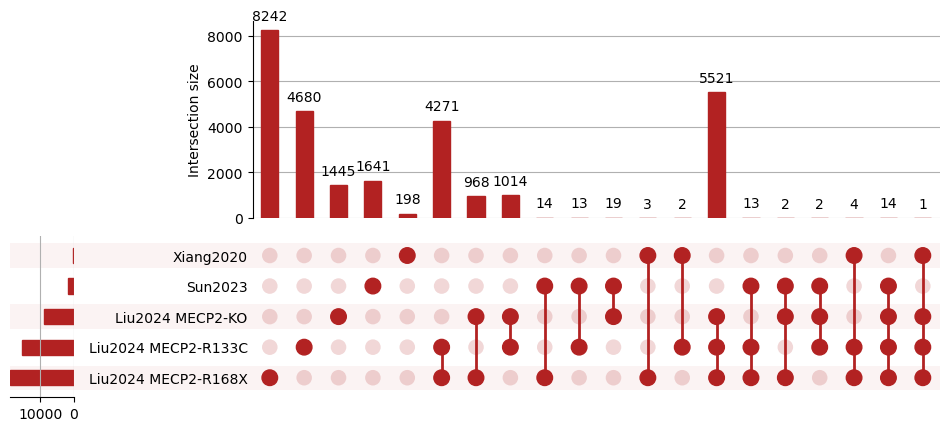

Número de TEs: 45500
     0       1       2                3     4  5             6     7     8   \
0  chr1   81232   81691  TE_Tigger5_dup1  2382  +  TcMar-Tigger   DNA  chr1   
1  chr1  197096  197166      TE_L2c_dup7   200  -            L2  LINE  chr1   
2  chr1  197313  197576    TE_AluSp_dup6  2050  +           Alu  SINE  chr1   
3  chr1  522955  523291  TE_AluSq2_dup17  1951  +           Alu  SINE  chr1   
4  chr1  524652  524930  TE_AluSx1_dup12  2085  +           Alu  SINE  chr1   

       9       10        11 12 13     14  
0   65418   71585     OR4F5  .  +   9648  
1  185216  195411    WASH9P  .  -   1686  
2  182695  184174  DDX11L17  .  +  13140  
3  487100  489906     CICP7  .  +  33050  
4  487100  489906     CICP7  .  +  34747  
Test TE_Classification
               TE_Name   baseMean  log2FoldChange     lfcSE      stat  \
0      TE_SVA_E_dup367  68.134215       10.011793  1.378326  7.263731   
1      TE_SVA_D_dup846  65.595823       -4.989282  0.711076 -7.016525   
2   

c:\Users\Ana\miniconda3\Lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
c:\Users\Ana\miniconda3\Lib\site-packages\upsetplot\plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

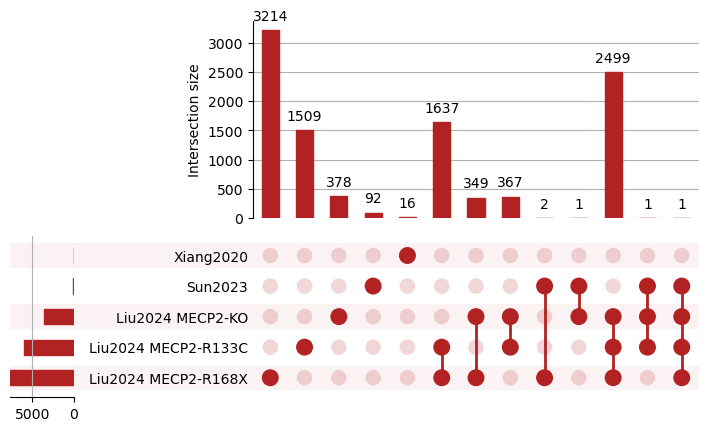

In [15]:
dea_strings = [SUN_TE_DEA, XIANG_TE_DEA, LIU_TE_DEA_MECP2_KO, LIU_TE_DEA_MECP2_R133C, LIU_TE_DEA_MECP2_R168X]
df_strings = [SUN_INTERGENIC, XIANG_INTERGENIC, LIU_INTERGENIC, LIU_INTERGENIC, LIU_INTERGENIC]

get_upset_plot("", dea_strings, "TE_MECP2_regulation.csv", num_intersection = 1) # All MECP2 TEs
get_upset_plot("", dea_strings, 'TE_MECPR_Intergenic_regulation.csv', num_intersection = 1, df_strings = df_strings) # Only intergenic


DETEs and intergenic DETEs - Upset plots RTT

Número de TEs: 5305
Número TEs no presence_df: 4839
Index(['Aldinger2020_Temporal_cortex', 'Goglioti2018_Cerebellum',
       'Goglioti2018_Motor_cortex', 'Rodrigues2020_NPC', 'Rodrigues2020_Neu',
       'Tanaka2014'],
      dtype='object', name='DataSet')
Presence_df
DataSet               Aldinger2020_Temporal_cortex  Goglioti2018_Cerebellum  \
TE_Name                                                                       
TE_7SK_dup396                                False                    False   
TE_7SK_dup524                                False                    False   
TE_ALR/Alpha_dup1558                         False                    False   
TE_ALR/Alpha_dup1560                         False                    False   
TE_ALR/Alpha_dup799                          False                    False   
...                                            ...                      ...   
TE_X9_LINE_dup82                             False                    False   
TE_Zaphod3_dup1068   

c:\Users\Ana\miniconda3\Lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
c:\Users\Ana\miniconda3\Lib\site-packages\upsetplot\plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

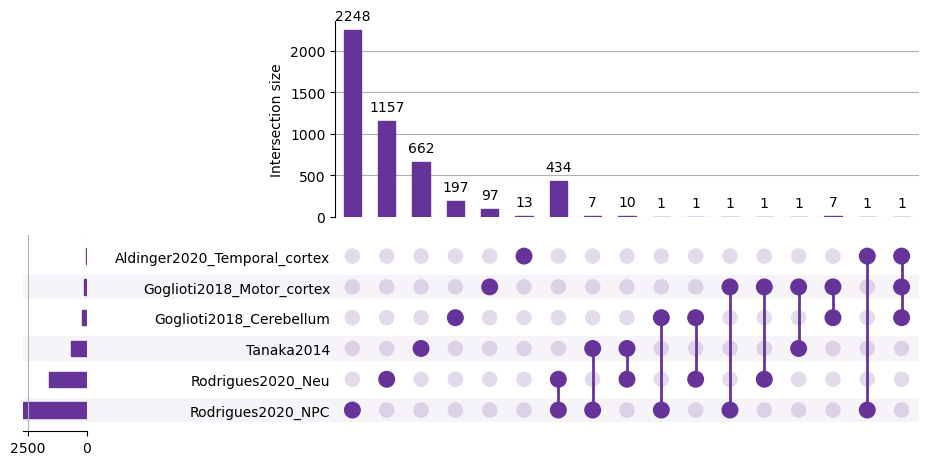

Número de TEs: 5305
     0        1        2               3      4  5     6     7     8   \
0  chr1  1017169  1018876  TE_LTR12C_dup1  11165  -  ERV1   LTR  chr1   
1  chr1  1408001  1408288  TE_AluJb_dup76   1799  +   Alu  SINE  chr1   
2  chr1  1408480  1408622   TE_L1MC4_dup4    281  -    L1  LINE  chr1   
3  chr1  1408762  1409016  TE_AluSz_dup42   1841  -   Alu  SINE  chr1   
4  chr1  1412251  1412721   TE_LTR2B_dup1   3762  -  ERV1   LTR  chr1   

        9        10               11 12 13    14  
0  1011996  1013193  ENSG00000224969  .  -  3977  
1  1409095  1410618        MRPL20-DT  .  +   808  
2  1401908  1407293           MRPL20  .  -  1188  
3  1401908  1407293           MRPL20  .  -  1470  
4  1401908  1407293           MRPL20  .  -  4959  
Test TE_Classification
Empty DataFrame
Columns: [TE_Name, baseMean, log2FoldChange, lfcSE, stat, pvalue, padj, -log10(padj), Classification, TE_Chr, TE_Classification]
Index: []
     0        1        2                      3      4  5

c:\Users\Ana\miniconda3\Lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
c:\Users\Ana\miniconda3\Lib\site-packages\upsetplot\plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

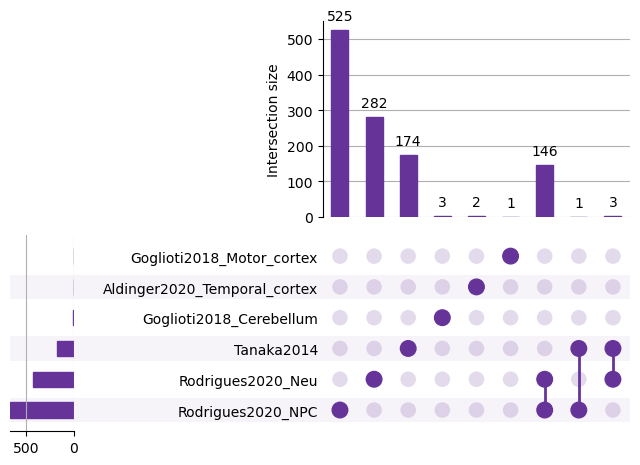

In [18]:
dea_strings = [ALDINGER_TE_CINGLUATE_CORTEX_DEA, ALDINGER_TE_TEMPORAL_CORTEX_DEA, GOGLIOTI_TE_CEREBELLUM_DEA,
               GOGLIOTI_TE_MOTOR_CORTEX_DEA, TANAKA_TE_DEA, RODRIGUES_TE_NEU_DEA, RODRIGUES_TE_NPC_DEA]

df_strings = [ALDINGER_CINGLUATE_CORTEX_INTERGENIC, ALDINGER_TEMPORAL_CORTEX_INTERGENIC, 
              GOGLIOTI_CEREBELLUM_INTERGENIC, GOGLIOTI_MOTOR_CORTEX_INTERGENIC, TANAKA_INTERGENIC, RODRIGUES_NEU_INTERGENIC, 
              RODRIGUES_NPC_INTERGENIC]

get_upset_plot("", dea_strings, "TE_RTT_regulation.csv", names_intersection = ["Goglioti", "Rodrigues"]) # All RTT TEs
get_upset_plot("", dea_strings, "TE_RTT_Intergenic_regulation.csv", names_intersection = ["Goglioti"], df_strings = df_strings) # Only intergenic

Genes - Upset plots MECP2 and RTT

Número de TEs: 30612
Número TEs no presence_df: 15696
Index(['Liu2024_KO', 'Liu2024_R133C', 'Liu2024_R168X', 'Sun2023', 'Xiang2020'], dtype='object', name='DataSet')
Presence_df
DataSet  Liu2024_KO  Liu2024_R133C  Liu2024_R168X  Sun2023  Xiang2020
TE_Name                                                              
A2M           False           True           True    False      False
A2ML1         False           True           True    False      False
AAAS          False           True           True    False      False
AACS          False           True          False    False      False
AACSP1        False           True           True    False      False
...             ...            ...            ...      ...        ...
ZXDB          False           True           True    False      False
ZXDC          False           True          False    False      False
ZYG11A        False           True           True    False      False
ZYG11B         True          False           True   

c:\Users\Ana\miniconda3\Lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
c:\Users\Ana\miniconda3\Lib\site-packages\upsetplot\plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

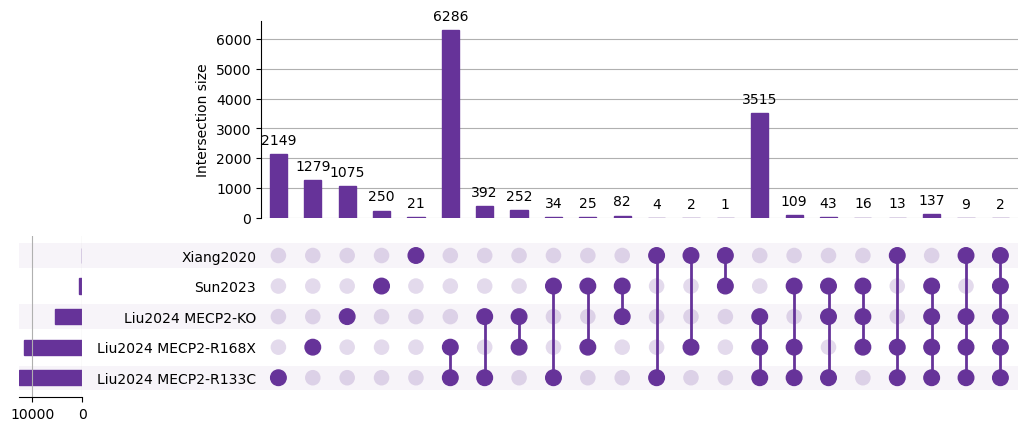

Número de TEs: 10286
Número TEs no presence_df: 7631
Index(['Aldinger2020_Cingluate_cortex', 'Aldinger2020_Temporal_cortex',
       'Goglioti2018_Cerebellum', 'Goglioti2018_Motor_cortex',
       'Rodrigues2020_NPC', 'Rodrigues2020_Neu', 'Tanaka2014'],
      dtype='object', name='DataSet')
Presence_df
DataSet    Aldinger2020_Cingluate_cortex  Aldinger2020_Temporal_cortex  \
TE_Name                                                                  
A2M                                False                         False   
A2ML1                              False                         False   
A2ML1-AS1                          False                         False   
AACS                               False                         False   
AACSP1                             False                         False   
...                                  ...                           ...   
ZSWIM4                             False                         False   
ZSWIM8                          

c:\Users\Ana\miniconda3\Lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
c:\Users\Ana\miniconda3\Lib\site-packages\upsetplot\plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

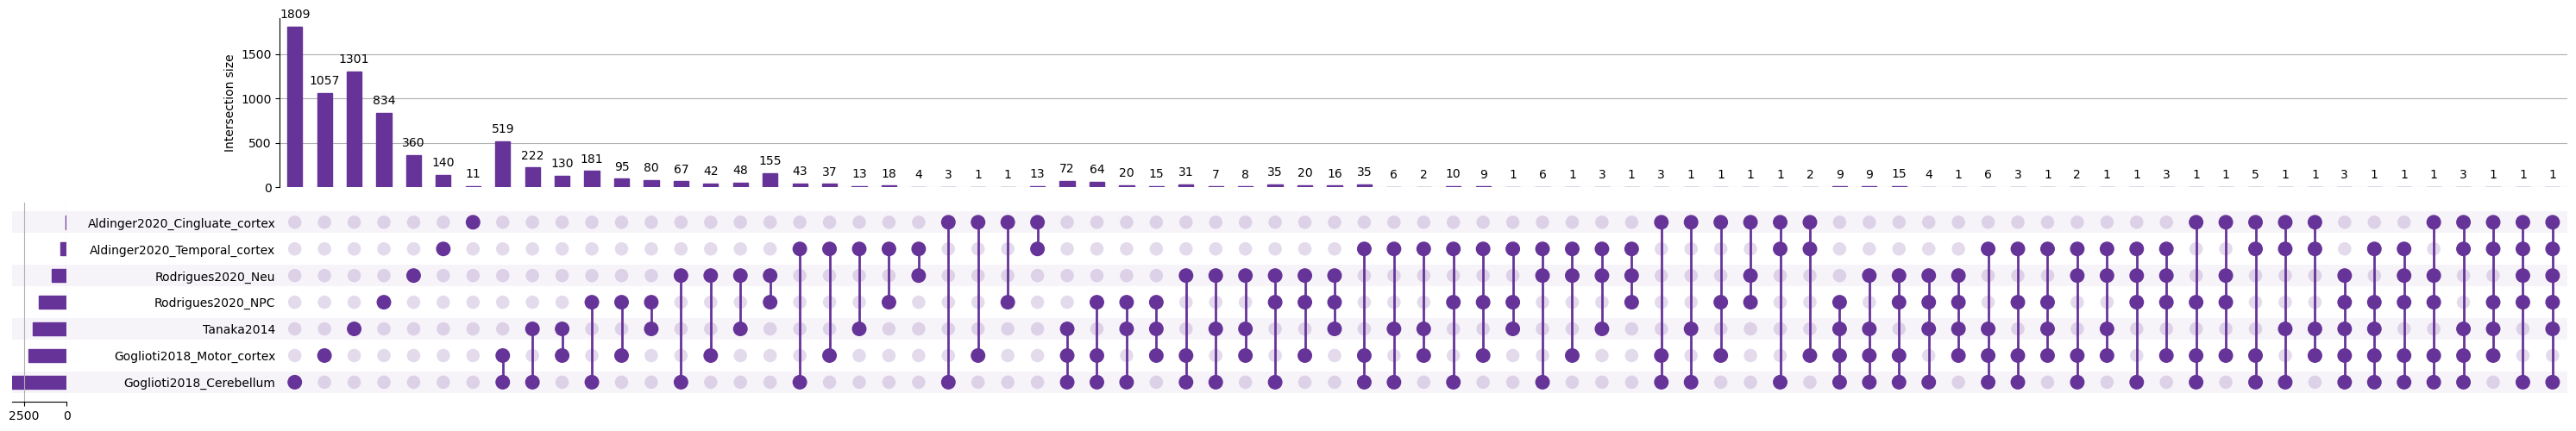

In [22]:
dea_strings = [SUN_GENES_DEA, XIANG_GENES_DEA, LIU_GENES_DEA_MECP2_KO, LIU_GENES_DEA_MECP2_R133C, LIU_GENES_DEA_MECP2_R168X]

get_upset_plot("", dea_strings, "Genes_MECP2_regulation.csv", num_intersection = 1) # All MECP2 Genes

dea_strings = [ALDINGER_GENES_CINGLUATE_CORTEX_DEA, ALDINGER_GENES_TEMPORAL_CORTEX_DEA, GOGLIOTI_GENES_CEREBELLUM_DEA,
               GOGLIOTI_GENES_MOTOR_CORTEX_DEA, TANAKA_GENES_DEA, RODRIGUES_GENES_NEU_DEA, RODRIGUES_GENES_NPC_DEA]

get_upset_plot("", dea_strings, "Genes_RTT_regulation.csv", num_intersection = 2) # All RTT Genes


Barplot classification Rodrigues2020

Número de TEs: 5305
     0         1         2                3     4  5          6           7   \
0  chr1   6466515   6466812  TE_AluSz_dup176  2137  +        Alu        SINE   
1  chr1  11305079  11306612    TE_SVA_C_dup2  9695  -        SVA  Retroposon   
2  chr1  13842901  13843186   TE_THE1D_dup35  1754  +  ERVL-MaLR         LTR   
3  chr1  16241468  16241573  TE_MLT1B_dup166   523  -  ERVL-MaLR         LTR   
4  chr1  16535843  16536004     TE_L2_dup253   367  +         L2        LINE   

     8         9         10               11 12 13     14  
0  chr1   6424775   6461367             ESPN  .  +   5149  
1  chr1  11311733  11319093  ENSG00000284646  .  -   5122  
2  chr1  13700187  13825079            PRDM2  .  +  17823  
3  chr1  16241212  16241398           MT1XP1  .  -     71  
4  chr1  16520693  16521796  ENSG00000224174  .  +  14048  
Test TE_Classification
            TE_Name   baseMean  log2FoldChange     lfcSE      stat    pvalue  \
0    TE_SVA_F_dup12  37.361376      

C:\Users\Ana\AppData\Local\Temp\ipykernel_4064\4147212263.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = intergenics_and_intragenics_df, x = 'TE_Classification', y = 'Total', palette = palette_barplot, edgecolor = 'black')


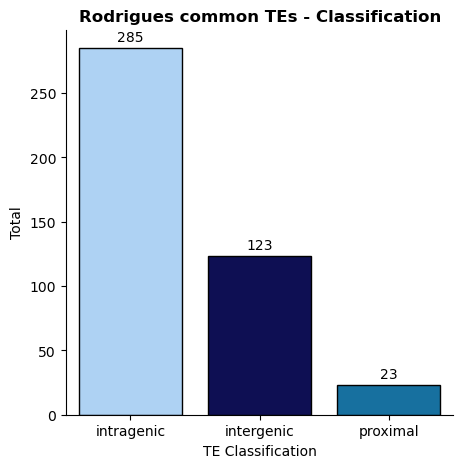

In [ ]:

def make_barplot(file_name, intergenic_dfs_strings, dea_strings, names = None, num_intersection = None):
    """Makes a barplot to know how many common DETEs are intergenic, proximal and intragenic"""

    # Obtain intergenic intersection
    df_all_intergenic, presence_df_intergenic = organize_deas(dea_strings, intergenic_dfs_strings)
    common_intergenic_dfs = print_genes_of_interest_intergenic(df_all_intergenic, presence_df_intergenic, file_name, names_intersection = names, num_intersection = num_intersection)
    print("position 0")
    print(common_intergenic_dfs[0])
    
    # Obtain all the tes in the intersection
    df_all, presence_df = organize_deas(dea_strings, None)
    all_common_dfs = print_genes_of_interest(df_all, presence_df, file_name, names_intersection = names, num_intersection = num_intersection)
    
    for i in range(len(common_intergenic_dfs)):
        
        # Get only the TEs with the same regulation on both data frames
        all_common_dfs[i] = all_common_dfs[i][all_common_dfs[i].nunique(axis = 1) == 1]
        common_intergenic_dfs[i] = common_intergenic_dfs[i][common_intergenic_dfs[i].drop(columns = ['TE_Classification']).nunique(axis = 1) == 1]

        print("Common intergenic df")
        print(common_intergenic_dfs[i])

        print("all common!")
        print(all_common_dfs[i])
        
        # Merge the common intergenic TEs with all the common TEs, if a TE is intergenic, it will appear both on the _merge column
        intergenics_and_intragenics_df = common_intergenic_dfs[i].merge(all_common_dfs[i], 
                                                                           on = 'TE_Name', 
                                                                           how = 'outer', 
                                                                           indicator = True)
        
        with pd.option_context('display.max_rows', None, 'display.max_columns', None):
            print(intergenics_and_intragenics_df)
        intergenics_and_intragenics_df.loc[intergenics_and_intragenics_df['_merge'] == "right_only", 'TE_Classification'] = 'intragenic'
        
    
        # Organize the data frame better
        new_values = {
            'left_only' : 'intragenic',
            'right_only' : 'intragenic',
            'both' : 'intergenic'
        }

        # print(intergenics_and_intragenics_df)


        # Make the barplot
        fig, ax = plt.subplots(figsize = (5,5))

        palette_barplot = {
            'intragenic' : '#a2d2ff',
            'proximal' : '#0077b6',
            'intergenic' : '#03045e'
        }

        # intergenics_and_intragenics_df = intergenics_and_intragenics_df[intergenics_and_intragenics_df.drop(columns = other_columns).nunique(axis = 1) == 1]
        intergenics_and_intragenics_df = intergenics_and_intragenics_df['TE_Classification'].value_counts().reset_index(name = 'Total')
    

        sns.barplot(data = intergenics_and_intragenics_df, x = 'TE_Classification', y = 'Total', palette = palette_barplot, edgecolor = 'black')
        
        for container in ax.containers:
            ax.bar_label(container, padding=3)

        ax.set_title('Rodrigues common TEs - Classification', fontweight = 'bold', fontsize = 12)
        ax.set_xlabel('TE Classification')

        sns.despine()
        plt.show()



dea_strings = [GOGLIOTI_TE_CEREBELLUM_DEA, GOGLIOTI_TE_MOTOR_CORTEX_DEA, ALDINGER_TE_CINGLUATE_CORTEX_DEA, 
               ALDINGER_TE_TEMPORAL_CORTEX_DEA, TANAKA_TE_DEA, RODRIGUES_TE_NEU_DEA, RODRIGUES_TE_NPC_DEA]
df_strings = [GOGLIOTI_CEREBELLUM_INTERGENIC, GOGLIOTI_MOTOR_CORTEX_INTERGENIC,
              ALDINGER_CINGLUATE_CORTEX_INTERGENIC, ALDINGER_TEMPORAL_CORTEX_INTERGENIC, TANAKA_INTERGENIC, 
              RODRIGUES_NEU_INTERGENIC, RODRIGUES_NPC_INTERGENIC ]


make_barplot("regulation.csv", df_strings, dea_strings, names = ['Rodrigues']) # Passar aqui um array com os titulos

Venn diagram with MECP2 DETEs and RTT DETEs

Número de TEs: 45500
Número de TEs: 5305


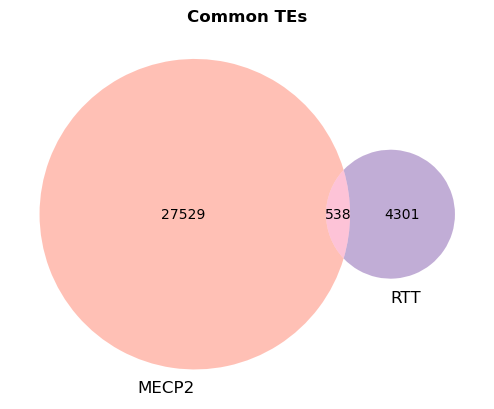

MECP2:
DataSet                 Liu2024_KO   Liu2024_R133C   Liu2024_R168X  \
TE_Name                                                              
TE_AluJb_dup116757  Down-regulated  Down-regulated  Down-regulated   
TE_AluJo_dup44211     Up-regulated    Up-regulated    Up-regulated   
TE_AluSx1_dup20243    Up-regulated    Up-regulated    Up-regulated   
TE_AluSx_dup20899     Up-regulated    Up-regulated    Up-regulated   
TE_AluSx_dup85534     Up-regulated    Up-regulated    Up-regulated   
TE_L1PA2_dup1298      Up-regulated    Up-regulated    Up-regulated   
TE_L1PA8A_dup137      Up-regulated    Up-regulated    Up-regulated   
TE_L1PB1_dup4494      Up-regulated    Up-regulated    Up-regulated   
TE_L1PB3_dup1547      Up-regulated    Up-regulated    Up-regulated   
TE_L2c_dup8231        Up-regulated    Up-regulated    Up-regulated   
TE_L3_dup13964      Down-regulated  Down-regulated  Down-regulated   
TE_LTR12C_dup1288   Down-regulated  Down-regulated  Down-regulated   
TE_MER58A_dup

In [ ]:
dea_strings_MECP2 = [SUN_TE_DEA, XIANG_TE_DEA, LIU_TE_DEA_MECP2_KO, LIU_TE_DEA_MECP2_R133C, LIU_TE_DEA_MECP2_R168X]
df_strings_MECP2 = [SUN_INTERGENIC, XIANG_INTERGENIC, LIU_INTERGENIC, LIU_INTERGENIC, LIU_INTERGENIC]

dea_strings_RTT = [ALDINGER_TE_CINGLUATE_CORTEX_DEA, ALDINGER_TE_TEMPORAL_CORTEX_DEA, GOGLIOTI_TE_CEREBELLUM_DEA,
               GOGLIOTI_TE_MOTOR_CORTEX_DEA, RODRIGUES_TE_NEU_DEA, RODRIGUES_TE_NPC_DEA, TANAKA_TE_DEA]

df_strings_RTT = [ALDINGER_CINGLUATE_CORTEX_INTERGENIC, ALDINGER_TEMPORAL_CORTEX_INTERGENIC, 
              GOGLIOTI_CEREBELLUM_INTERGENIC, GOGLIOTI_MOTOR_CORTEX_INTERGENIC, TANAKA_INTERGENIC]

def cross_MECP2_RTT(dea_strings_MECP2, dea_strings_RTT, file_names, names = None, num_intersection = None):
    """Makes a venn driagram that shows which DETEs are present in at least one MECP2 dataset and one RTT dataset"""

    # Obtain MECP2
    df_all_MECP2, presence_df_MECP2 = organize_deas(dea_strings_MECP2, None)
    MECP2_dfs = print_genes_of_interest(df_all_MECP2, presence_df_MECP2, None, num_intersection = num_intersection)
    
    # Obtain RTT
    df_all_RTT, presence_df_RTT = organize_deas(dea_strings_RTT, None)
    RTT_dfs = print_genes_of_interest(df_all_RTT, presence_df_RTT, None, names_intersection = names)

    
    venn2(subsets = (set(df_all_MECP2['TE_Name']), set(df_all_RTT['TE_Name'])),
            set_labels = ('MECP2', 'RTT'), 
            set_colors = ('tomato', 'rebeccapurple'))
    
    plt.title("Common TEs", fontweight = 'bold', fontsize = 12)
    plt.show()

    # Make an individual csv for each RTT data set and MECP2 intersection
    for i in range(len(RTT_dfs)):
        print("MECP2:")
        print(MECP2_dfs[0])
        print("RTT:")

        with pd.option_context('display.max_rows', None, 'display.max_columns', None):
            print(RTT_dfs[i])

        tmp_df = MECP2_dfs[0].merge(RTT_dfs[i], on = 'TE_Name', how = 'inner')
        tmp_df.to_csv(file_names[i], index = True)

    # Make a csv for all RTT data sets and MECP2 intersection
    merged_df = MECP2_dfs[0]
    for i in range(len(RTT_dfs)):
        
        print("Last MECP2:")
        print(merged_df)
        print("RTT:")
        print(RTT_dfs[i])

        merged_df = merged_df.merge(RTT_dfs[i], on = 'TE_Name', how = 'inner')
    merged_df.to_csv(file_names[-1], index = True)
        


cross_MECP2_RTT(dea_strings_MECP2, dea_strings_RTT, ['Goglioti_MECP2_intersection.csv', 'Rodrigues_MECP2_intersection.csv', 'RTT_MECP2_intersection.csv'], names = ['Goglioti'], num_intersection = 1)

Upset plot liu and RTT datasets

Número de TEs: 48199
Número TEs no presence_df: 30034
Index(['Aldinger2020_Temporal_cortex', 'Goglioti2018_Cerebellum',
       'Goglioti2018_Motor_cortex', 'Liu2024_KO', 'Liu2024_R133C',
       'Liu2024_R168X', 'Rodrigues2020_NPC', 'Rodrigues2020_Neu'],
      dtype='object', name='DataSet')
Presence_df
DataSet             Aldinger2020_Temporal_cortex  Goglioti2018_Cerebellum  \
TE_Name                                                                     
TE_(GAATG)n_dup11                          False                    False   
TE_7SK_dup198                              False                    False   
TE_7SK_dup396                              False                    False   
TE_7SK_dup524                              False                    False   
TE_ACRO1_dup16                             False                    False   
...                                          ...                      ...   
TE_Zaphod3_dup1049                         False                    False   
TE_

c:\Users\Ana\miniconda3\Lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
c:\Users\Ana\miniconda3\Lib\site-packages\upsetplot\plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

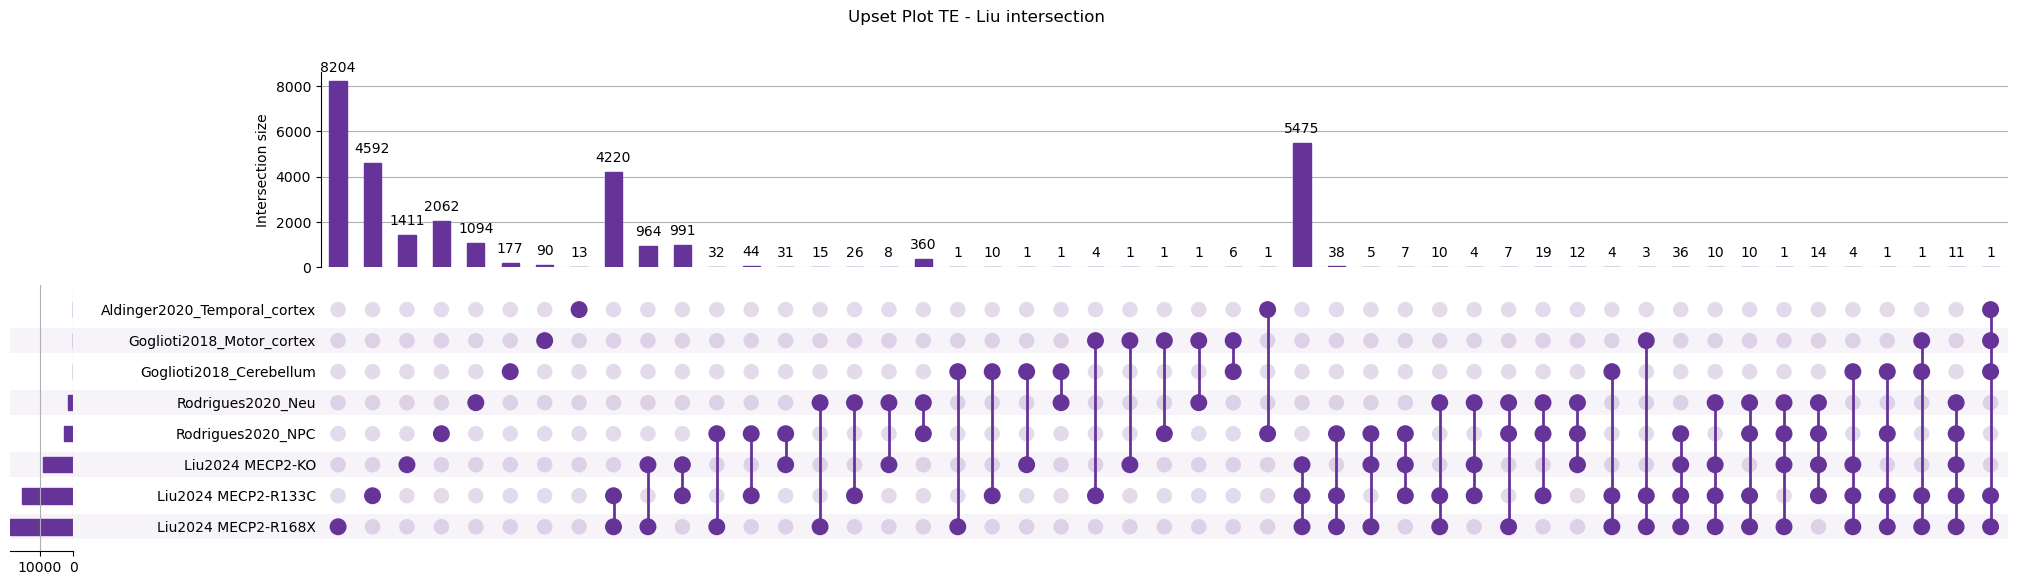

MemoryError: Unable to allocate 1.00 MiB for an array with shape (131072,) and data type float64

In [24]:
dea_strings = [LIU_TE_DEA_MECP2_KO, LIU_TE_DEA_MECP2_R133C, LIU_TE_DEA_MECP2_R168X, GOGLIOTI_TE_CEREBELLUM_DEA, GOGLIOTI_TE_MOTOR_CORTEX_DEA,
               ALDINGER_TE_CINGLUATE_CORTEX_DEA, ALDINGER_TE_TEMPORAL_CORTEX_DEA, RODRIGUES_TE_NEU_DEA, RODRIGUES_TE_NPC_DEA]
df_strings = [LIU_INTERGENIC, LIU_INTERGENIC, LIU_INTERGENIC, GOGLIOTI_CEREBELLUM_INTERGENIC, GOGLIOTI_MOTOR_CORTEX_INTERGENIC,
              ALDINGER_CINGLUATE_CORTEX_INTERGENIC, ALDINGER_TEMPORAL_CORTEX_INTERGENIC, 
              RODRIGUES_NEU_INTERGENIC, RODRIGUES_NPC_INTERGENIC ]

    
get_upset_plot("Upset Plot TE - Liu intersection", dea_strings, "TE_Liu_regulation.csv", num_intersection = 1) # All MECP2 TEs
get_upset_plot("Upset Plot TE intergenic - Liu intersection", dea_strings, 'TE_Liu_Intergenic_regulation.csv', 
               num_intersection = 1, df_strings = df_strings) # Only intergenic

Upset plots Sun and RTT

Número de TEs: 7023
Número TEs no presence_df: 6520
Index(['Aldinger2020_Temporal_cortex', 'Goglioti2018_Cerebellum',
       'Goglioti2018_Motor_cortex', 'Rodrigues2020_NPC', 'Rodrigues2020_Neu',
       'Sun2023', 'Tanaka2014'],
      dtype='object', name='DataSet')
Presence_df
DataSet               Aldinger2020_Temporal_cortex  Goglioti2018_Cerebellum  \
TE_Name                                                                       
TE_7SK_dup396                                False                    False   
TE_7SK_dup524                                False                    False   
TE_ALR/Alpha_dup1174                         False                    False   
TE_ALR/Alpha_dup1558                         False                    False   
TE_ALR/Alpha_dup1560                         False                    False   
...                                            ...                      ...   
TE_X9_LINE_dup82                             False                    False   
TE_Zaphod3

c:\Users\Ana\miniconda3\Lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
c:\Users\Ana\miniconda3\Lib\site-packages\upsetplot\plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

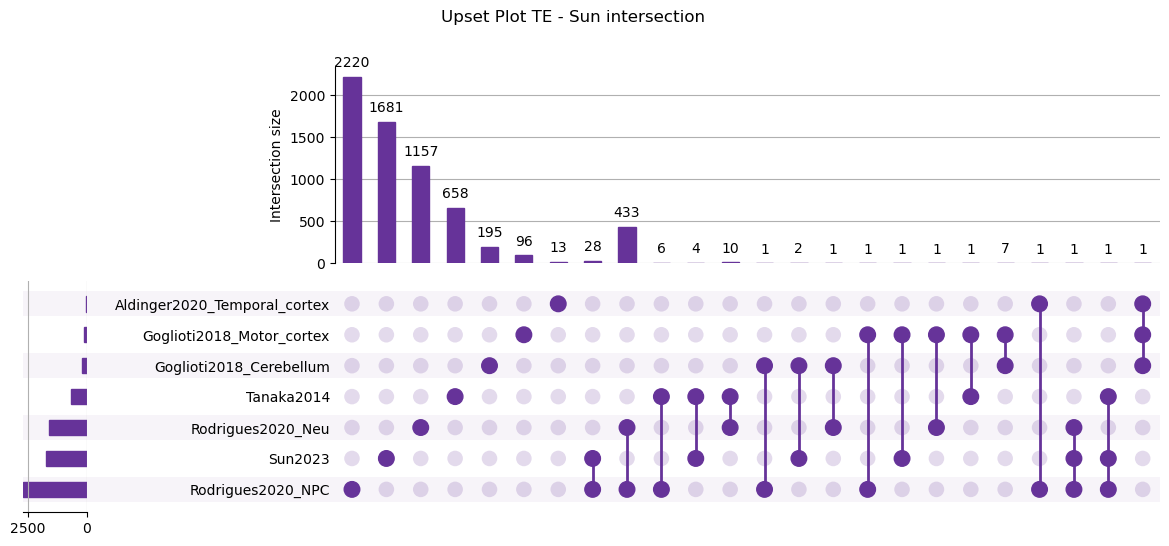

Número de TEs: 7023
     0       1       2                3     4  5             6     7     8   \
0  chr1   81232   81691  TE_Tigger5_dup1  2382  +  TcMar-Tigger   DNA  chr1   
1  chr1  197096  197166      TE_L2c_dup7   200  -            L2  LINE  chr1   
2  chr1  197313  197576    TE_AluSp_dup6  2050  +           Alu  SINE  chr1   
3  chr1  522955  523291  TE_AluSq2_dup17  1951  +           Alu  SINE  chr1   
4  chr1  524652  524930  TE_AluSx1_dup12  2085  +           Alu  SINE  chr1   

       9       10        11 12 13     14  
0   65418   71585     OR4F5  .  +   9648  
1  185216  195411    WASH9P  .  -   1686  
2  182695  184174  DDX11L17  .  +  13140  
3  487100  489906     CICP7  .  +  33050  
4  487100  489906     CICP7  .  +  34747  
Test TE_Classification
               TE_Name   baseMean  log2FoldChange     lfcSE      stat  \
0      TE_SVA_E_dup367  68.134215       10.011793  1.378326  7.263731   
1      TE_SVA_D_dup846  65.595823       -4.989282  0.711076 -7.016525   
2    

c:\Users\Ana\miniconda3\Lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
c:\Users\Ana\miniconda3\Lib\site-packages\upsetplot\plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

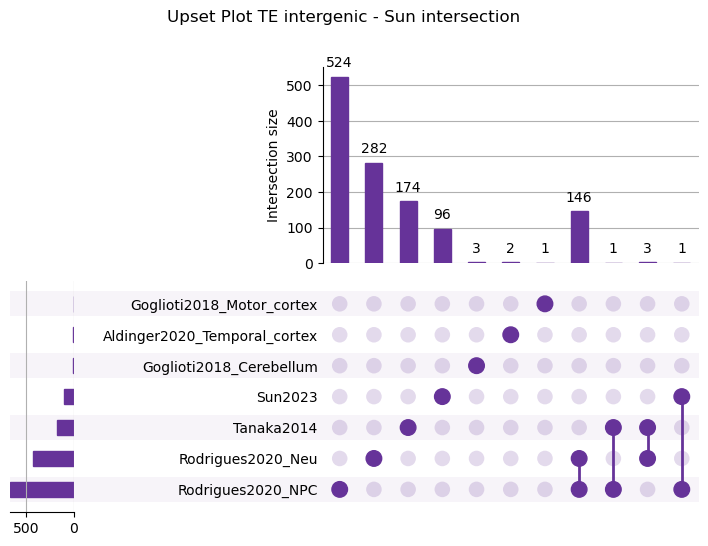

In [25]:
dea_strings = [SUN_TE_DEA, GOGLIOTI_TE_CEREBELLUM_DEA, GOGLIOTI_TE_MOTOR_CORTEX_DEA,
               ALDINGER_TE_CINGLUATE_CORTEX_DEA, ALDINGER_TE_TEMPORAL_CORTEX_DEA, RODRIGUES_TE_NEU_DEA, RODRIGUES_TE_NPC_DEA,
               TANAKA_TE_DEA]

df_strings = [SUN_INTERGENIC, GOGLIOTI_CEREBELLUM_INTERGENIC, GOGLIOTI_MOTOR_CORTEX_INTERGENIC,
              ALDINGER_CINGLUATE_CORTEX_INTERGENIC, ALDINGER_TEMPORAL_CORTEX_INTERGENIC, 
              RODRIGUES_NEU_INTERGENIC, RODRIGUES_NPC_INTERGENIC, TANAKA_INTERGENIC]

get_upset_plot("Upset Plot TE - Sun intersection", dea_strings, "TE_Sun_regulation.csv", num_intersection = 1) # All MECP2 TEs
get_upset_plot("Upset Plot TE intergenic - Sun intersection", dea_strings, 'TE_Sun_Intergenic_regulation.csv', 
               num_intersection = 1, df_strings = df_strings) # Only intergenic

Venn diagram intergenic DETEs between Rodrigues2020 and Liu2024 MECP2-KO

Número de TEs: 13281
     0      1      2               3     4  5    6     7     8      9      10  \
0  chr1  40307  40626     TE_L2a_dup3   747  +   L2  LINE  chr1  29553  31109   
1  chr1  48416  49518  TE_L1PA14_dup1  5956  +   L1  LINE  chr1  52472  53312   
2  chr1  51584  51880  TE_AluYj4_dup1  2373  +  Alu  SINE  chr1  52472  53312   
3  chr1  54464  54703      TE_L2_dup1   529  +   L2  LINE  chr1  52472  53312   
4  chr1  54818  54938  TE_FLAM_A_dup1   680  -  Alu  SINE  chr1  34553  36081   

            11 12 13     14  
0  MIR1302-2HG  .  +   9199  
1       OR4G4P  .  +   2955  
2       OR4G4P  .  +    593  
3       OR4G4P  .  +   1153  
4      FAM138A  .  -  18738  
     0       1       2              3     4  5            6     7     8   \
0  chr1  197095  197166    TE_L2c_dup7   200  -           L2  LINE  chr1   
1  chr1  197312  197576  TE_AluSp_dup6  2050  +          Alu  SINE  chr1   
2  chr1  197790  198040  TE_MER33_dup2  1297  +  hAT-Charlie   DNA  chr1   
3  chr1 

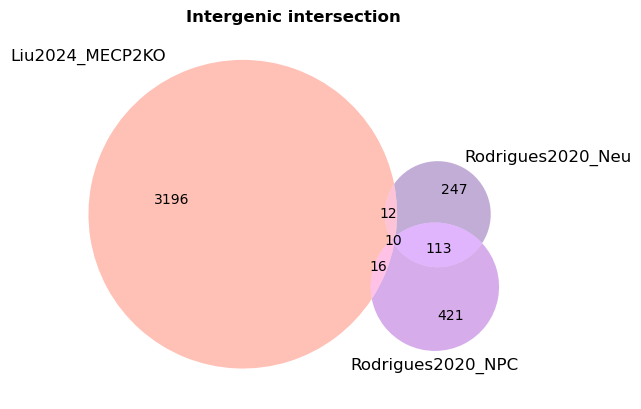

In [ ]:
dea_strings = [LIU_TE_DEA_MECP2_KO, RODRIGUES_TE_NEU_DEA, RODRIGUES_TE_NPC_DEA]
df_strings = [LIU_INTERGENIC, RODRIGUES_NEU_INTERGENIC, RODRIGUES_NPC_INTERGENIC]


def make_venn_diagram(dea_strings, df_strings):
    """Makes a venn diagram between Liu2024 MECP2-KO intergenic DETEs and Rodrigues2020 intergenic DETEs"""

    dea_dfs, names = read_deas(dea_strings)

    if (df_strings is not None): # is not supostamente é mais seguro que != qnd se compara com none
        dfs_intergenic, dea_dfs = merge_intergenic_with_dea(df_strings, dea_dfs)
    
    for df_intergenic in dfs_intergenic:
        print('intergenic')
        print(df_intergenic)
    
    for dea_df in dea_dfs:
        print('dea')
        print(dea_df)
        
    venn3(subsets = (set(dea_dfs[0]['TE_Name']), set(dea_dfs[1]['TE_Name']), set(dea_dfs[2]['TE_Name'])), 
            set_labels = ('Liu2024_MECP2KO', 'Rodrigues2020_Neu', 'Rodrigues2020_NPC'), 
            set_colors = ('tomato', 'rebeccapurple', 'darkorchid'))
    
    plt.title('Intergenic intersection', fontsize = 12, fontweight = 'bold')
    plt.show()

make_venn_diagram(dea_strings, df_strings)

Venn diagram intergenic DETEs between MECP2 and RTT

Número de TEs: 45500
     0       1       2                3     4  5             6     7     8   \
0  chr1   81232   81691  TE_Tigger5_dup1  2382  +  TcMar-Tigger   DNA  chr1   
1  chr1  197096  197166      TE_L2c_dup7   200  -            L2  LINE  chr1   
2  chr1  197313  197576    TE_AluSp_dup6  2050  +           Alu  SINE  chr1   
3  chr1  522955  523291  TE_AluSq2_dup17  1951  +           Alu  SINE  chr1   
4  chr1  524652  524930  TE_AluSx1_dup12  2085  +           Alu  SINE  chr1   

       9       10        11 12 13     14  
0   65418   71585     OR4F5  .  +   9648  
1  185216  195411    WASH9P  .  -   1686  
2  182695  184174  DDX11L17  .  +  13140  
3  487100  489906     CICP7  .  +  33050  
4  487100  489906     CICP7  .  +  34747  
     0       1       2                   3     4  5     6     7     8   \
0  chr1  200408  200714       TE_L1MB3_dup2  1294  +    L1  LINE  chr1   
1  chr1  894861  895173      TE_AluSp_dup21  2383  -   Alu  SINE  chr1   
2  chr1  895289  895508 

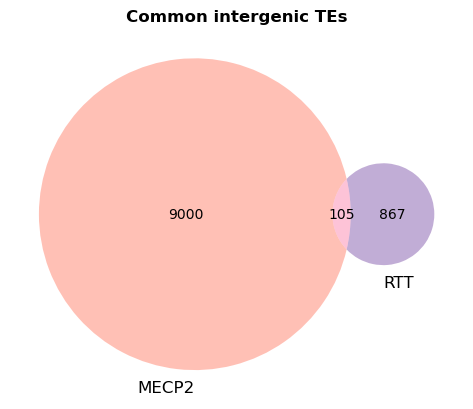

In [ ]:
dea_strings_MECP2 = [SUN_TE_DEA, XIANG_TE_DEA, LIU_TE_DEA_MECP2_KO, LIU_TE_DEA_MECP2_R133C, LIU_TE_DEA_MECP2_R168X]
df_strings_MECP2 = [SUN_INTERGENIC, XIANG_INTERGENIC, LIU_INTERGENIC, LIU_INTERGENIC, LIU_INTERGENIC]

dea_strings_RTT = [ALDINGER_TE_CINGLUATE_CORTEX_DEA, ALDINGER_TE_TEMPORAL_CORTEX_DEA, GOGLIOTI_TE_CEREBELLUM_DEA,
               GOGLIOTI_TE_MOTOR_CORTEX_DEA, RODRIGUES_TE_NEU_DEA, RODRIGUES_TE_NPC_DEA, TANAKA_TE_DEA]

df_strings_RTT = [ALDINGER_CINGLUATE_CORTEX_INTERGENIC, ALDINGER_TEMPORAL_CORTEX_INTERGENIC, 
              GOGLIOTI_CEREBELLUM_INTERGENIC, GOGLIOTI_MOTOR_CORTEX_INTERGENIC, RODRIGUES_NEU_INTERGENIC, 
              RODRIGUES_NPC_INTERGENIC, TANAKA_INTERGENIC]


def cross_MECP2_RTT(dea_strings_MECP2, dea_strings_RTT):
    """
    Makes a venn diagram between intergenic DETEs in MECP2 datasets and intergenic DETEs in RTT datasets, showing
    how many intergenic DETEs appear in at least one MECP2 and one RTT dataset.
    """

    # Obtain MECP2
    df_all_MECP2, presence_df_MECP2 = organize_deas(dea_strings_MECP2, df_strings_MECP2)
    
    # Obtain RTT
    df_all_RTT, presence_df_RTT = organize_deas(dea_strings_RTT, df_strings_RTT)
    
    venn2(subsets = (set(df_all_MECP2['TE_Name']), set(df_all_RTT['TE_Name'])),
            set_labels = ('MECP2', 'RTT'), 
            set_colors = ('tomato', 'rebeccapurple'))
    
    plt.title('Common intergenic TEs', fontsize = 12, fontweight = 'bold')
    plt.show()
        


cross_MECP2_RTT(dea_strings_MECP2, dea_strings_RTT)

Log2FC csvs

In [ ]:
dea_strings = [SUN_TE_DEA, XIANG_TE_DEA, LIU_TE_DEA_MECP2_KO, LIU_TE_DEA_MECP2_R133C, LIU_TE_DEA_MECP2_R168X,
                     ALDINGER_TE_CINGLUATE_CORTEX_DEA, ALDINGER_TE_TEMPORAL_CORTEX_DEA, GOGLIOTI_TE_CEREBELLUM_DEA,
               GOGLIOTI_TE_MOTOR_CORTEX_DEA, RODRIGUES_TE_NEU_DEA, RODRIGUES_TE_NPC_DEA, TANAKA_TE_DEA]

df_strings = [SUN_INTERGENIC, XIANG_INTERGENIC, LIU_INTERGENIC, LIU_INTERGENIC, LIU_INTERGENIC,
                    ALDINGER_CINGLUATE_CORTEX_INTERGENIC, ALDINGER_TEMPORAL_CORTEX_INTERGENIC, 
                    GOGLIOTI_CEREBELLUM_INTERGENIC, GOGLIOTI_MOTOR_CORTEX_INTERGENIC, RODRIGUES_NEU_INTERGENIC, 
                    RODRIGUES_NPC_INTERGENIC, TANAKA_INTERGENIC]

dea_genes_strings = [SUN_GENES_DEA, XIANG_GENES_DEA, LIU_GENES_DEA_MECP2_KO, LIU_GENES_DEA_MECP2_R133C, LIU_GENES_DEA_MECP2_R168X,
                     ALDINGER_GENES_CINGLUATE_CORTEX_DEA, ALDINGER_GENES_TEMPORAL_CORTEX_DEA, GOGLIOTI_GENES_CEREBELLUM_DEA,
                     GOGLIOTI_GENES_MOTOR_CORTEX_DEA, RODRIGUES_GENES_NEU_DEA, RODRIGUES_GENES_NPC_DEA, TANAKA_GENES_DEA]


def get_te_classification(dea_strings, df_strings):
    """Gets the df_all always with the TE Classification"""

    dea_dfs, names = read_deas(dea_strings)

    dfs_intergenic, dea_dfs = get_intergenic_classification(df_strings, dea_dfs)

    dea_dict = dict(zip(names, dea_dfs)) # zip junta par a par

    df_all = concat_deas(dea_dict)
    df_all.rename(columns = {'Unnamed: 0' : 'TE_Name'}, inplace = True)
    presence_df = pd.crosstab(index = df_all['TE_Name'], columns = df_all['DataSet']).astype(bool)

    return df_all, presence_df



def get_intergenic_classification(df_strings, dea_dfs):
    """
    Gets the intergenic TEs and merges them with the DEA to 
    get the TE classification (show intergenic, intragenic and proximal)
    """

    intergenic_dfs = []
    dea_dfs = rename_deas(dea_dfs)

    for i in range(len(df_strings)):
        df = pd.read_csv(df_strings[i], sep = '\t', header = None)
        print(df.head())
        df.columns = ['TE_Chr', 'TE_Start', 'TE_End', 'TE_Name', 'TE_Score', 'TE_Strand', 'TE_Class-id', 'TE_Family_id',
                 'Gene_Chr', 'Gene_Start', 'Gene_End', 'Gene_Name', 'Gene_Score', 'Gene_Strand', 'Distances']
        
        df['TE_Classification'] = np.where(df['Distances'] <= 4000, 'proximal', 'intergenic')
        df = df[['TE_Name', 'TE_Chr', 'TE_Classification']]
                
        intergenic_dfs.append(df)
        dea_dfs[i] = dea_dfs[i].merge(df, on = 'TE_Name', how = 'left')
        dea_dfs[i]['TE_Classification'] = dea_dfs[i]['TE_Classification'].fillna('intragenic')
        print('Test TE_Classification')
        print(dea_dfs[i])

    return intergenic_dfs, dea_dfs


def get_tes_log2FC(dea_strings, df_strings):
    """Gets the DETEs log2FC into a csv"""

    df_all, presence_df = get_te_classification(dea_strings, df_strings)
    df_all = df_all[df_all['Classification'] != 'Non-significant']
    logFC_values = df_all.pivot(index = 'TE_Name', columns = 'DataSet', values = 'log2FoldChange')
    print(df_all)
    te_metadata = df_all[['TE_Name', 'TE_Classification']].drop_duplicates('TE_Name').set_index('TE_Name')
    logFC_values = logFC_values.join(te_metadata, how = 'left') # I can use join instead of merge when they have the same index

    datasets = df_all['DataSet'].unique()

    logFC_values = logFC_values.dropna(subset = datasets, how = 'all')

    print(logFC_values)
    logFC_values.to_csv('logFC_values_tes.csv', index = True)
    print('size')
    print(len(logFC_values))


def get_genes_log2FC(dea_genes_strings):
    """Gets the genes log2FC into a csv"""

    df_all, presence_df = organize_deas(dea_genes_strings, None)
    df_all = df_all[df_all['Classification'] != 'Non-significant']
    logFC_values = df_all.pivot(index = 'TE_Name', columns = 'DataSet', values = 'log2FoldChange')
    print(df_all)
    datasets = df_all['DataSet'].unique()

    logFC_values = logFC_values.dropna(subset = datasets, how = 'all')

    print(logFC_values)
    logFC_values.to_csv('logFC_values_genes.csv', index = True)
    print('size')
    print(len(logFC_values))


get_tes_log2FC(dea_strings, df_strings)
get_genes_log2FC(dea_genes_strings)

Número de TEs: 50821
     0       1       2                3     4  5             6     7     8   \
0  chr1   81232   81691  TE_Tigger5_dup1  2382  +  TcMar-Tigger   DNA  chr1   
1  chr1  197096  197166      TE_L2c_dup7   200  -            L2  LINE  chr1   
2  chr1  197313  197576    TE_AluSp_dup6  2050  +           Alu  SINE  chr1   
3  chr1  522955  523291  TE_AluSq2_dup17  1951  +           Alu  SINE  chr1   
4  chr1  524652  524930  TE_AluSx1_dup12  2085  +           Alu  SINE  chr1   

       9       10        11 12 13     14  
0   65418   71585     OR4F5  .  +   9648  
1  185216  195411    WASH9P  .  -   1686  
2  182695  184174  DDX11L17  .  +  13140  
3  487100  489906     CICP7  .  +  33050  
4  487100  489906     CICP7  .  +  34747  
Test TE_Classification
                 TE_Name    baseMean  log2FoldChange     lfcSE       stat  \
0     TE_AluSx1_dup13054  163.991600        4.763657  0.449558  10.596317   
1       TE_MIR3_dup46734  462.762811        5.127197  0.536516   9.55